# Aperture — 孔径: 圆孔 + 圆柱堵块

本 notebook 是官方算例系列教学之一 (全部位于 examples/ 目录): 只跑这一个官方算例, 逐步解读输入卡、展示本算例最有代表性的图。

In [1]:
%run ../notebooks/_bootstrap.py

astra-notebook 后端已加载 (v0.1.0)
项目根目录: /Users/yuxinwu/my_projects/astra_notebook
模拟工作目录: /Users/yuxinwu/my_projects/astra_notebook/data/workspace
ASTRA    : /Users/yuxinwu/programs/ASTRA/astra
Generator: /Users/yuxinwu/programs/ASTRA/generator


In [2]:
# ===== 共享规格 (单一数据源, 与 06 汇总一致) =====
from examples._examples_spec import (
    EXAMPLES, run_example, phase_files, compare_xemit)
NAME = "Aperture"
STEM = "astra"
print("算例:", NAME, "| 物理:", EXAMPLES[NAME]["title"])


算例: Aperture | 物理: 孔径: 圆孔 + 圆柱堵块


In [3]:
# ===== 运行本算例 (generator/astra 按需) =====
work = run_example(NAME)
print("输出文件:")
for f in sorted(work.glob(STEM + ".*")):
    print("  ", f.name)

 --------------------------------------------------------------------------

                     Astra- A space charge tracking algorithm     
               Version 4.0 - macOS 64bit - OpenMPI - Apple Silicon
                              DESY,  Hamburg 2022                 
                         15. 8.2026  21:56

     Parameter file is:  astra.in                                          
     Aperture test - circular + beam stop                                            

 Initialize element settings:
     neglecting space charge forces 

 --------------------------------------------------------------------------
 Aperture:

 --------------------------------------------------------------------------
     500 particles from file test.ini                                          

     Particles taken into account      N =        500
     total charge                      Q =     -1.000     nC
     horizontal beam position          x =     3.1742E-05 mm
     vertical beam positio

In [4]:
# ===== 束团统计 (最后一个 z 位置) =====
from astra_tools.io import read_distribution
from astra_tools.analysis.statistics import compute_statistics, print_statistics
from astra_tools.widgets.panels import stats_table_html
ph = phase_files(work, STEM)
dist = read_distribution(ph[-1])
print("相空间文件:", ph[-1].name)
print_statistics(compute_statistics(dist),
                 title="%s @ %s" % (NAME, ph[-1].name))
stats_table_html(compute_statistics(dist))

相空间文件: astra.0190.001

  Aperture @ astra.0190.001
  Particles:            500 total,      500 active,      0 passive,
                         0 lost,      0 not started
  Total charge:        1.0000 nC (|Q| shown; sign kept internally)
----------------------------------------
  Ref. momentum:     250.5100 MeV/c
  Ref. kinetic E:    249.9995 MeV
  gamma:             490.2369
  beta:              0.999998
----------------------------------------
  Centroid x:          0.0000 mm
  Centroid y:          0.0000 mm
  Centroid z:       1900.0002 mm
  sigma_x:             0.0800 mm
  sigma_y:             0.0800 mm
  sigma_z:             0.9998 mm
----------------------------------------
  Mean pz:           250.5100 MeV/c
  sigma_p/p:         0.000010
  Mean E_kin:        249.9995 MeV
  sigma_E:             2.4443 keV
  sigma_E/E:         0.000010
----------------------------------------
  eps_x (geom):        0.0020 um.rad
  eps_y (geom):        0.0020 um.rad
  eps_nx:              1.0000 um

quantity,value,unit
n_particle,500,
n_active,500,
n_passive,0,
n_lost,0,
n_not_started,0,
total_charge_nC,1 (|Q|),nC
mean_x_mm,3.17424e-05,mm
mean_y_mm,1.76458e-05,mm
mean_z_mm,1900,mm
sig_x_mm,0.0799939,mm


### 教学要点

&APERTURE namelist 定义孔径元件 (Ap_Z1/Ap_Z2/Ap_R, 单位 mm, 负半径 = 堵块)。展示束包络与孔径几何的叠加图。

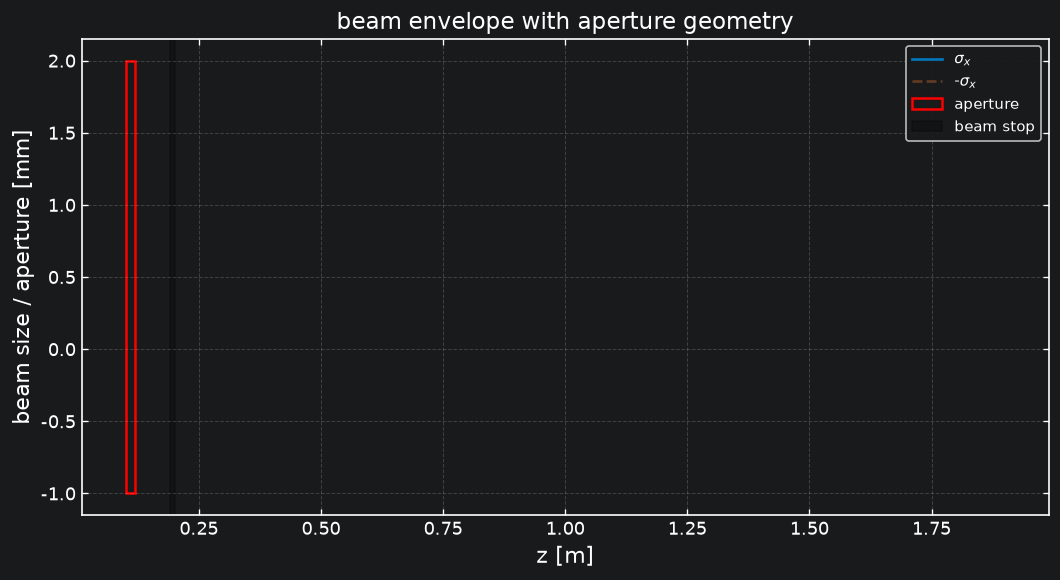

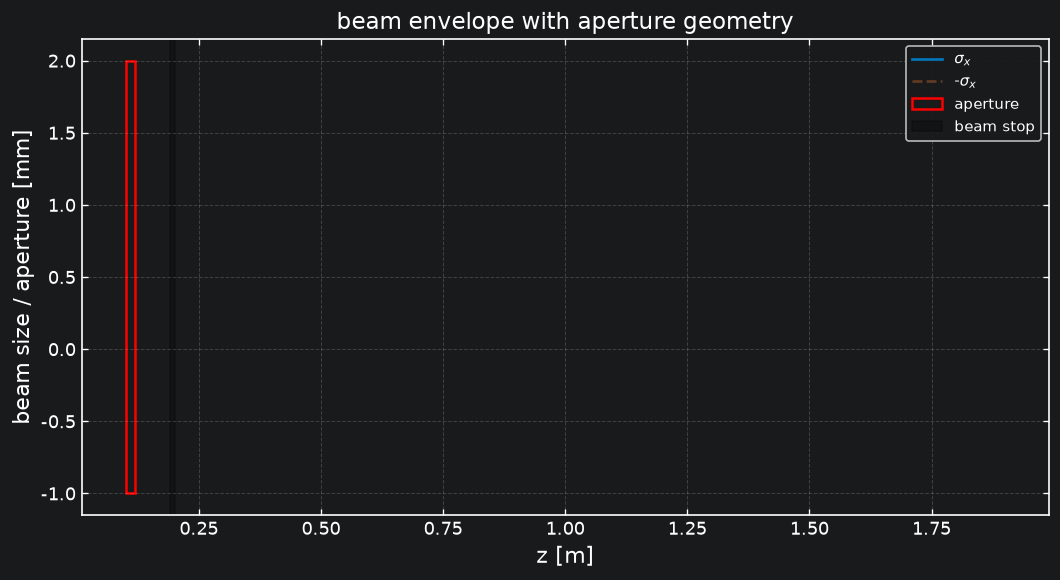

In [5]:
from astra_tools.namelist.parse import parse_namelists
from astra_tools.io.astra_emit import read_emit_files
from astra_tools.plot.advanced_plots import (
    aperture_elements, plot_envelope_with_aperture)
ap = parse_namelists(PROJECT_ROOT / "examples/Aperture/astra.in")["APERTURE"]
emit_ap = read_emit_files(str(work / STEM))
plot_envelope_with_aperture(emit_ap, aperture_elements(ap))

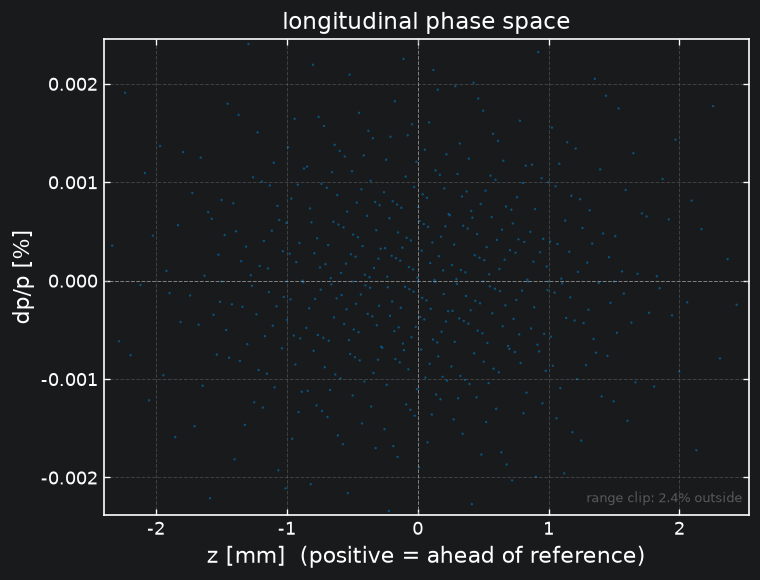

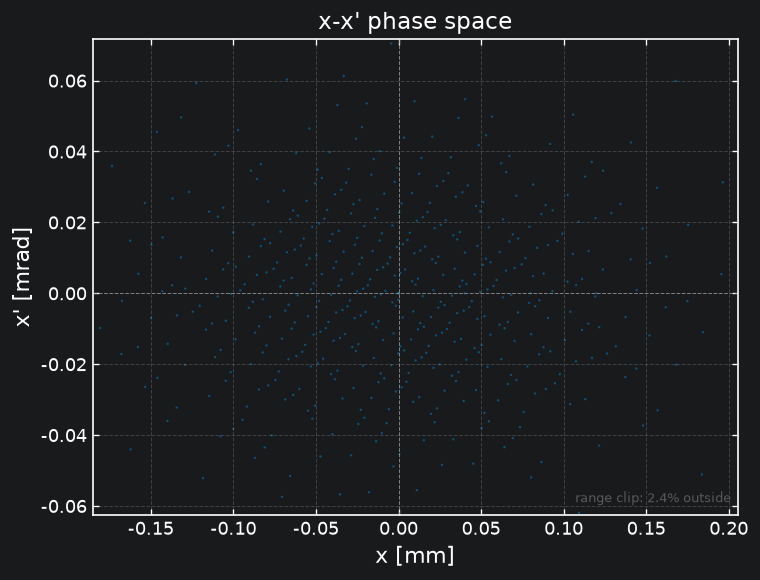

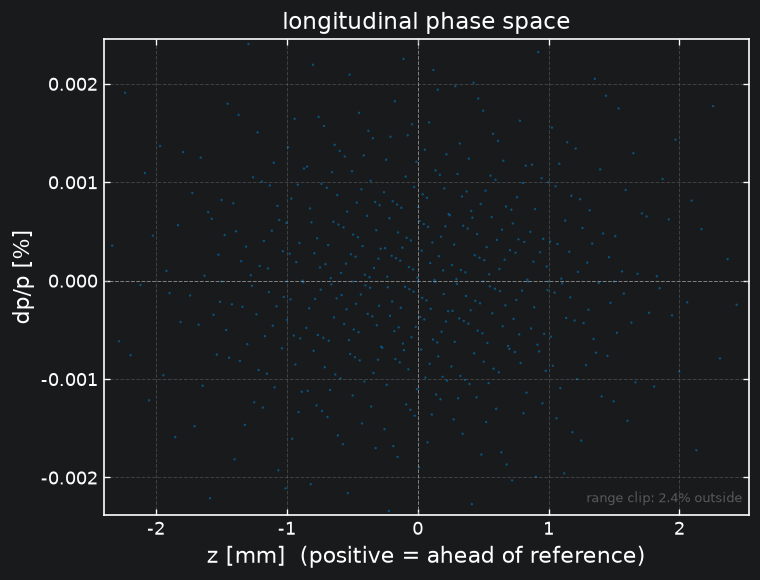

In [6]:
from astra_tools.plot.phase_space import plot_phase_space
plot_phase_space(dist, plane="x")
plot_phase_space(dist, plane="z")

In [7]:
# ===== 黄金比对 (rel < 0.5% 判 OK) =====
compare_xemit(NAME, work)
print("其他官方算例的教学 notebook 同样位于 examples/ 目录")

  末行比对 (new vs golden):
    norm_emit_x    1e-06      1e-06      rel=0.0000% OK
    sigma_x        7.9994e-05 7.9994e-05 rel=0.0000% OK
    mean_z         1.9        1.9        rel=0.0000% OK
返回汇总: notebooks/06_examples.ipynb
